### download weights from HF

In [ ]:
from transformers import pipeline

generator = pipeline("text-generation", model="gpt2")

save_path = "./gpt2-weights"
generator.save_pretrained(save_path)

print(f"Done. Model and tokenizer saved to {save_path}")

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.67it/s]

Done. Model and tokenizer saved to ./gpt2-weights


### inference

In [302]:
from transformers import pipeline
generator = pipeline("text-generation", model="./gpt2-weights")

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 678.36it/s]


In [304]:
output = generator(
    "The Eiffel Tower is located in the city of",
    max_new_tokens=30,
    do_sample=True,
    top_k=30,
    temperature=0.4,
)

print(output[0]["generated_text"])

The Eiffel Tower is located in the city of Paris, and is the tallest building in the world. It is located in the heart of the city, and is the tallest building in the world.


### hooks

In [305]:
import matplotlib.pyplot as plt

In [306]:
import torch as t
import numpy as np
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained("gpt2")

In [307]:
from transformer_lens.model_bridge import TransformerBridge

bridge = TransformerBridge.boot_transformers("gpt2", device="cpu")

prompt = "The cat sat on the mat. The cat sat on the"
logits, cache = bridge.run_with_cache(prompt) # cache contains all internal activations

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 296.45it/s]


In [308]:
for key in list(cache.keys())[:15]:
    print(key, cache[key].shape)

embed.hook_in torch.Size([1, 13])
embed.hook_out torch.Size([1, 13, 768])
hook_embed torch.Size([1, 13, 768])
pos_embed.hook_in torch.Size([1, 13])
pos_embed.hook_out torch.Size([1, 13, 768])
hook_pos_embed torch.Size([1, 13, 768])
blocks.0.hook_in torch.Size([1, 13, 768])
blocks.0.hook_resid_pre torch.Size([1, 13, 768])
blocks.0.ln1.hook_in torch.Size([1, 13, 768])
blocks.0.ln1.hook_scale torch.Size([1, 13, 1])
blocks.0.ln1.hook_normalized torch.Size([1, 13, 768])
blocks.0.ln1.hook_out torch.Size([1, 13, 768])
blocks.0.attn.hook_in torch.Size([1, 13, 768])
blocks.0.attn.q.hook_in torch.Size([1, 13, 768])
blocks.0.attn.q.hook_out torch.Size([1, 13, 12, 64])


In [315]:
tokens = bridge.to_tokens(prompt)
str_tokens = bridge.to_str_tokens(prompt)

# attention pattern for layer 5, head 1
pattern = cache["blocks.5.attn.hook_pattern"][0, 5]  # [batch, head number]. pattern is an 11x11 attention matrix

for i, tok in enumerate(str_tokens):
    top_src = pattern[i].argmax().item()
    print(f"{tok!r:>15} attends most to {str_tokens[top_src]!r}")

'<|endoftext|>' attends most to '<|endoftext|>'
          'The' attends most to '<|endoftext|>'
         ' cat' attends most to '<|endoftext|>'
         ' sat' attends most to '<|endoftext|>'
          ' on' attends most to '<|endoftext|>'
         ' the' attends most to '<|endoftext|>'
         ' mat' attends most to '<|endoftext|>'
            '.' attends most to '<|endoftext|>'
         ' The' attends most to '<|endoftext|>'
         ' cat' attends most to ' sat'
         ' sat' attends most to ' on'
          ' on' attends most to ' the'
         ' the' attends most to '<|endoftext|>'


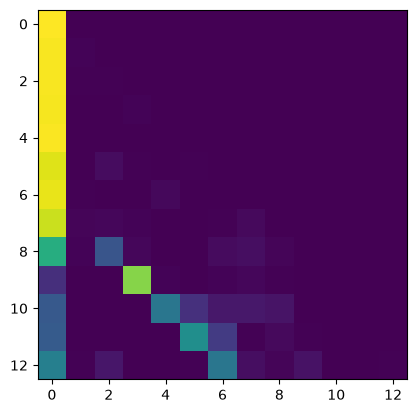

In [316]:
plt.imshow(pattern)

## Experiments

#### 1. Identifying confidence direction $v$ (binary HC vs LC)

1. Come up with high confidence (HC, e.g. the sun will rise tomorrow) and low confidence (LC, e.g. Paris is the best city in the world) statements
2. With HC and LC inputs, measure activations $a$ at each layer for final token.
3. Find layer $L$ where difference of mean activations best predicts HC vs LC, and extract the corresponding vector $v$.

#### 2. Checking if $v$ is causal

1. Input HC statements, ask model to self-report confidence $c$.
2. Input HC statements, change activation at layer $L$ to $a' = a-v$, ask model to self-report confidence $c'$.
3. Hypothesis: $c' < c$.
4. Repeat for LC statements: $a' = a+v$.

Note: we're making the assumption that self-reported confidence accurately reflects internal confidence.
This seems at odds with the goal of wanting to inspect internal confidence because we don't trust self-reported confidence.
However, I think it's reasonable to assume (given a sufficiently good model) that self-reported and internal confidence are correlated for simple prompts.

The hope is that when this correlation breaks down for more complicated prompts, $v$ is a better measure of internal confidence than the self-reported confidence.
The way we would demonstrate this is to get the model to hallucinate and self-report high confidence, but measure $v$ and observe low internal confidence.

Of course, it is possible that we fail and that $v$ is always correlated with self-reported confidence, e.g. when the model is hallucinating, both self-reported confidence and confidence inferred from $v$ are high. This would suggest that either 1) the $v$ we have identified is an internal representation of self-reported confidence, not true internal confidence, or 2) that when the model is hallucinating, it has high internal confidence and is truthfully reporting its internal confidence.

#### 3. Checking if $v$ applies to continuous confidence

1. Come up with statements where we can quantify confidence $x$ (e.g. a randomly drawn card is red, $x=0.5$).
2. Measure activations $a$ at layer $L$.
3. Hypothesis: $a \cdot v$ is correlated with $x$.

#### 4. Checking if $v$ is causal for continuous confidence

1. Input statements with quantifiable confidence $x$, ask model to self-report $c$. We should observe $c=x$.
2. Input statements and change activation at layer $L$: $a' = a + \theta v$, then ask model to self-report $c'$.
3. Hypothesis: $a' \cdot v$ and $c'$ exhibit the relationship observed between $a \cdot v$ and $x$ in Step 3 of Experiment 3.